# Pension Fund Risk Forecasting Using Machine Learning
## Notebook 1 of 4: Data Cleaning and Exploratory Data Analysis

**Author:** Kanwarjit Singh Dhariwal | **Program:** UC Berkeley PCMLAI Capstone

### This Capstone Is Split Into 4 Notebooks

1. **Data Cleaning and EDA** (this notebook) -- loads and cleans all 7 raw government data files, engineers features, handles outliers, and explores the clean data
2. **Modeling and Evaluation** -- builds and compares every model I tried (regression, classification, and a neural network), all cross-validated and grid-searched
3. **Fresno Case Study and Findings** -- a detailed look at the City of Fresno's two pension funds, including a forecast and statistical significance test
4. **Reusable Pipeline and Findings** -- a general-purpose function that runs this same analysis on any California city or county, demonstrated on real examples, plus the overall capstone findings

**What this notebook needs:** the 7 raw CSV files (listed below).
**What this notebook hands off:** a cleaned, merged, feature-engineered dataset (`model_ready_panel_clean.csv`), which every notebook after this one loads at the start.

### Research Question

Are California's public pension funds becoming more financially risky over time, and can that risk -- along with the key factors driving it -- be forecasted using historical actuarial and financial data? I use the City of Fresno's two pension funds as a close-up case study throughout, to keep the abstract statewide numbers grounded in something concrete.

### What I'm Doing, and the Techniques I'm Using in This Notebook

- **Data cleaning and merging** -- pulling seven separate government files, figuring out what's wrong with each one, and fixing it
- **Feature engineering** -- building new columns (net cash flow, contribution-to-payroll ratio, year-over-year funded ratio change) useful for spotting patterns
- **Outlier analysis** -- catching and investigating values that looked wrong before trusting them in any chart or model
- **Exploratory data analysis (EDA)** -- correlation checks, distribution charts, and trend charts, to see what the data actually says before assuming anything

### How This Notebook Works

This investigation happens in **two passes**. First, a fast, uniform scan across all seven data files -- just enough to know what I'm dealing with. Then, for the files that matter most, a much deeper dive: reading every column, understanding what each one means, and checking whether the numbers relate to each other the way they should. Every step follows the same pattern: why I need this piece of evidence, what it actually looks like, what I found, and what I did about it -- with the code and its real output sitting directly under every claim I make.

## Glossary

| Term | Meaning |
|---|---|
| **AAL** | Actuarial Accrued Liability — total amount a fund will eventually owe |
| **AVA** | Actuarial Value of Assets — money the fund actually has, smoothed over years |
| **UAAL** | Unfunded Actuarial Accrued Liability — the gap: `AAL − AVA` |
| **Funded Ratio** | `AVA ÷ AAL × 100`. 100% = fully funded |
| **MVA** | Market Value of Assets — a real, unsmoothed snapshot of assets |
| **ACP** | Annual Covered Payroll |
| **FY** | Fiscal Year |
| **DB / DC** | Defined Benefit (traditional pension, has a funded ratio) vs. Defined Contribution (401k-style, no funded ratio) |
| **ADC** | Actuarially Determined Contribution — what a fund *should* pay each year |
| **Contribution Deficiency** | `ADC − Actual Contribution`. Positive = underpaid |
| **MAE / RMSE / R²** | Model accuracy scores — MAE/RMSE measure average error size (lower = better), R² measures how much variation the model explains (0-1, higher = better) |
| **Cross-Validation** | A way of testing a model fairly: split the training data into several chunks, train on some, test on the rest, rotate through all combinations, then average the results. This avoids getting a lucky (or unlucky) score from just one split. |
| **Grid Search** | An automated way to find the best settings for a model (like how strict a penalty to apply) by trying every combination in a list and keeping whichever one performs best under cross-validation. |
| **Decision Tree** | A model that makes predictions through a series of simple yes/no questions, like a flowchart -- easy to read and explain, unlike most other models. |
| **PCA (Principal Component Analysis)** | A technique that looks at several related numbers and finds the main underlying "directions" of variation hiding in them -- useful for spotting when multiple features are really just telling the same story (like fund size). |
| **SHAP** | A technique that measures exactly how much each individual feature pushed a specific prediction up or down, giving a clear, quantified answer to "what factors actually drove this result." |

## Setup

In [1]:
# Core libraries for data handling, plotting, and modeling
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")  # cleaner default look for all charts in this notebook
%matplotlib inline

## Step 1: What Evidence Do I Have?

Answering this question needs more than one number — I need a fund's obligations, its assets, how its investments performed, and how it's been contributing, all tracked over many years. No single government file has all of that in one place, so I'm working with seven files from the California State Controller's Office.

### Data Sources — File Names, Download Links, and What Each One Tells Me

| # | File Name (used in this notebook) | Download Link | What It Tells Me | Years Covered |
|---|---|---|---|---|
| 1 | `export.csv` | [Download](https://bythenumbers.sco.ca.gov/api/v3/views/xd4u-ydgs/export.csv?accessType=DOWNLOAD) | Funding Position (core numbers): AAL, AVA, UAAL, Funded Ratio | FY2003-2016 |
| 2 | `Funding_Position_for_Fiscal_Years_2016-17_to_2023-24.csv` | [Download](https://bythenumbers.sco.ca.gov/api/views/yp57-bgvx/rows.csv?accessType=DOWNLOAD) | Same core numbers, more recent years | FY2017-2024 |
| 3 | `Retirement_Systems_-_Additions.csv` | [Download](https://bythenumbers.sco.ca.gov/api/views/w4mn-kbdb/rows.csv?accessType=DOWNLOAD) | Money coming in: contributions, investment income | FY2003-2022 |
| 4 | `Retirement_Systems_-_Deductions.csv` | [Download](https://bythenumbers.sco.ca.gov/api/views/tghp-v9pz/rows.csv?accessType=DOWNLOAD) | Money going out: benefit payments, refunds | FY2003-2023 |
| 5 | `Rate_of_Return_for_Fiscal_Years_2002-03_to_2015-16.csv` | [Download](https://bythenumbers.sco.ca.gov/api/views/22d8-yd9n/rows.csv?accessType=DOWNLOAD) | Investment performance, older years | FY2003-2016 |
| 6 | `Rate_of_Return_for_Fiscal_Years_2016-17_to_2023-24.csv` | [Download](https://bythenumbers.sco.ca.gov/api/views/kkkd-2prb/rows.csv?accessType=DOWNLOAD) | Investment performance, recent years | FY2017-2024 |
| 7 | `Contribution_Amounts_for_Fiscal_Years_2016-17_to_2023-24.csv` | [Download](https://bythenumbers.sco.ca.gov/api/views/5kqd-v7x4/rows.csv?accessType=DOWNLOAD) | Whether a fund contributed what its actuary recommended | FY2017-2024 |

All seven files come from the California State Controller's Office "By the Numbers" open data platform (https://bythenumbers.sco.ca.gov). I loaded each one directly using its file name above — those are the exact names you'll see show up in the `pd.read_csv(...)` calls throughout this notebook, so it should always be clear which file I'm working with at any point.

Files 1-2 are my foundation — the actual funded-ratio numbers this whole notebook is about. Files 3-4 help explain the cash flow behind those numbers. Files 5-6 tell me how much of that cash flow came from investment performance versus other sources. File 7 turned out to be one of the more useful pieces of evidence I found — it tells me not just what a fund contributed, but whether that was enough, according to the fund's own actuary.

## Step 2: First Pass — A Fast, Uniform Scan of All Seven Files

**Why:** Before I spend a lot of time understanding any one file deeply, I want a quick, honest read on all seven at once, using the same checks each time — shape, data types, missing values, duplicates, and any text columns that look like they should actually be numbers. This tells me where the real problems are, so I know where to focus my deeper attention next.

In [2]:
def audit_file(path, label):
    """Runs a standard set of checks on any raw CSV."""

    # Load the file fresh -- no assumptions about what's in it yet
    df = pd.read_csv(path)

    # Basic shape check: how many rows and columns am I actually working with?
    print(f"{label}  --  {df.shape[0]} rows x {df.shape[1]} columns")

    # df.duplicated() flags every row that's an exact copy of an earlier row
    # (True = duplicate). .sum() counts how many True values there are,
    # since True is treated as 1 and False as 0.
    print(f"Duplicate rows: {df.duplicated().sum()}")

    # df.isna() checks every cell for missing/blank values (True if missing).
    # .sum() here adds up the True values PER COLUMN, so I get a count of
    # how many missing values each individual column has.
    missing = df.isna().sum()
    print(f"\nMissing values (columns with >0 missing):")

    # missing[missing > 0] filters the column-missing-counts down to only the
    # columns that actually have at least one missing value -- no point
    # printing a long list of columns with zero missing values.
    # (missing > 0).any() checks: is there ANY column with missing data at all?
    # If yes, print the filtered list; if no, just say "(none)" instead of
    # printing an empty result.
    print(missing[missing > 0].to_string() if (missing > 0).any() else "  (none)")

    # Now check for a sneakier problem: columns that LOOK like they should
    # contain numbers, but are actually stored as text (this happens when a
    # numeric column has commas in it, like "1,234,567" -- pandas can't tell
    # that's a number, so it stores the whole column as text/object type).
    print(f"\nColumns stored as text that MIGHT actually be numbers:")
    found = False  # tracks whether I found at least one suspicious column

    # Build a list of columns that pandas is storing as text (object/str dtype),
    # since a genuinely numeric column (int64, float64) wouldn't have this problem
    text_cols = [c for c in df.columns if df[c].dtype == object or df[c].dtype.name == "str"]

    for col in text_cols:
        # Grab a small sample (first 20 non-missing values) from this column,
        # converted to string, just to check the pattern -- no need to scan
        # the whole column for a quick sanity check
        sample = df[col].dropna().astype(str).head(20)

        # Strip out characters that are totally normal in a formatted number
        # (commas for thousands, periods for decimals, minus signs for negatives),
        # then check if what's LEFT is purely digits. If most of the sample
        # passes this test, the column is probably a number wearing a text disguise.
        looks_numeric = sample.str.replace(",", "").str.replace(".", "").str.replace("-", "").str.isdigit()

        # If over half the sampled values look numeric once cleaned up,
        # flag this column as a likely candidate for conversion later
        if len(sample) > 0 and looks_numeric.mean() > 0.5:
            print(f"  '{col}' -- example: {sample.iloc[0]!r}")  # !r shows the raw repr, so I can see quotes/commas clearly
            found = True

    # If I never flagged anything above, say so explicitly rather than
    # leaving a blank/confusing gap in the output
    if not found:
        print("  (none detected)")

    # Return the loaded dataframe so I can keep using it in later cells
    # without having to re-read the CSV from disk again
    return df

### 2a-2b. Funding Position (both files)

In [3]:
old_raw = audit_file("export.csv", "Funding Position (2003-2016)")

Funding Position (2003-2016)  --  1826 rows x 13 columns
Duplicate rows: 0

Missing values (columns with >0 missing):
Valuation Date                                                  574
Name of Actuary                                                 145
Actuarial Accrued Liability_Funding Position                    624
Actuarial Value of Assets                                       654
Funded Ratio (Rounded to Nearest Tenth, Example: 99.9) (%)      643
Annual Covered Payroll_Funding Position                          84
UAAL as a Percenrate of ACP (%)                                 812
Select Method Used to Determine Actuarial Accrued Liability     624
Please Specifiy Other Method                                   1771

Columns stored as text that MIGHT actually be numbers:
  'Actuarial Accrued Liability_Funding Position' -- example: '856,235,546'
  'Actuarial Value of Assets' -- example: '570,994,244'
  'Unfunded Actuarial Accrued Liability (UAAL)' -- example: '0'
  'Annual Covered P

In [4]:
new_raw = audit_file("Funding_Position_for_Fiscal_Years_2016-17_to_2023-24.csv", "Funding Position (2017-2024)")

Funding Position (2017-2024)  --  687 rows x 16 columns
Duplicate rows: 0

Missing values (columns with >0 missing):
Name of Actuary                                                             12
Actuarial Accrued Liability (AAL)                                           23
Actuarial Value of Assets (AVA)                                             39
Unfunded Actuarial Accrued Liability (UAAL) (AVA Basis)                     36
Funded Ratio (AVA Basis) (rounded to nearest hundredth, EXAMPLE: 99.99)     69
Annual Covered Payroll (ACP)                                                 1
UAAL as a Percentage of ACP (AVA Basis)                                    223
Please Specifiy "Other" Method                                             625
Market Value of Assets (MVA)                                                65
UAAL (MVA Basis)                                                            63
Funding Ratio (MVA Basis)                                                   94

Columns store

### 2c-2d. Additions and Deductions

In [5]:
_ = audit_file("Retirement_Systems_-_Additions.csv", "Additions")

Additions  --  44934 rows x 11 columns
Duplicate rows: 0

Missing values (columns with >0 missing):
Entity Type     102
Value          1167

Columns stored as text that MIGHT actually be numbers:
  'Zip Code' -- example: '95340'


In [6]:
_ = audit_file("Retirement_Systems_-_Deductions.csv", "Deductions")

Deductions  --  40012 rows x 11 columns
Duplicate rows: 0

Missing values (columns with >0 missing):
Entity Type      84
Value          1296

Columns stored as text that MIGHT actually be numbers:
  'Zip Code' -- example: '94229-2703'


### 2e-2f. Rate of Return (both files)

In [7]:
_ = audit_file("Rate_of_Return_for_Fiscal_Years_2002-03_to_2015-16.csv", "Rate of Return (2003-2016)")

Rate of Return (2003-2016)  --  1402 rows x 9 columns
Duplicate rows: 0

Missing values (columns with >0 missing):
1 year_Dollar-Weighted Rate of Return     924
3 year_Dollar-Weighted Rate of Return    1005
5 year_Dollar-Weighted Rate of Return    1015
1 year_Time-Weighted Rate of Return       568
3 year_Time-Weighted Rate of Return       595
5 year_Time-Weighted Rate of Return       596

Columns stored as text that MIGHT actually be numbers:
  (none detected)


In [8]:
_ = audit_file("Rate_of_Return_for_Fiscal_Years_2016-17_to_2023-24.csv", "Rate of Return (2017-2024)")

Rate of Return (2017-2024)  --  693 rows x 10 columns
Duplicate rows: 0

Missing values (columns with >0 missing):
1 year_Dollar-Weighted Rate of Return                              316
3 year_Dollar-Weighted Rate of Return                              422
5 year_Dollar-Weighted Rate of Return                              431
1 year_Time-Weighted Rate of Return                                295
3 year_Time-Weighted Rate of Return                                298
5 year_Time-Weighted Rate of Return                                300
Annual Money-Weight Rate of Return, Net of Investment Expense %     21

Columns stored as text that MIGHT actually be numbers:
  (none detected)


### 2g. Contribution Amounts (ADC)

In [9]:
_ = audit_file("Contribution_Amounts_for_Fiscal_Years_2016-17_to_2023-24.csv", "Contribution Amounts")

Contribution Amounts  --  684 rows x 8 columns
Duplicate rows: 0

Missing values (columns with >0 missing):
Actuarially Determined Contributions_Employer Contributions                                     42
Contributions in Relation to the Actuarially Determined Contributions_Employer Contributions    53
Contribution Deficiency (Excess)_Employer Contributions                                         30
Contributions as a Percentage of Covered-Employee Payroll_Employer Contributions                12

Columns stored as text that MIGHT actually be numbers:
  (none detected)


**What this first pass told me:** zero duplicate rows in every single file, which was a relief. Only Funding Position's older file has real text-as-number columns (4 of them: AAL, AVA, UAAL, ACP). `Zip Code` got flagged as a possible number in Additions/Deductions, which turned out to be a **false positive** — zip codes look numeric but should stay as text, since nobody does math on a zip code. Missingness patterns vary file to file but every one of them has an explanation once I looked closer.

**Where I decided to focus next:** Funding Position (my core numbers) and Contribution Amounts (my sharpest piece of evidence) both need a much closer look — Funding Position because it genuinely needs cleaning, Contribution Amounts because it directly answers part of my research question. That's Steps 3 and 6 below. Additions/Deductions and Rate of Return need lighter attention — mostly format and coverage checks, which I cover in Steps 4 and 5.

## Step 3: Second Pass, Deep Dive — Funding Position (My Core Numbers)

**Why:** This is the file my entire research question depends on. Step 2 already flagged the surface-level problems (text-as-numbers, missing values). Now I want to go further: read every column, figure out what each one actually means, and check whether the numbers relate to each other the way they're supposed to — before I trust any of it.

### 3a. Loading the File and Looking at Everything

In [10]:
# Load the newer Funding Position file as-is, no cleaning yet -- just looking
df3 = pd.read_csv("Funding_Position_for_Fiscal_Years_2016-17_to_2023-24.csv")
print("Shape:", df3.shape)
print(f"\nColumn count: {len(df3.columns)}")
print("All data types:")
print(df3.dtypes)  # checking which columns pandas read as numbers vs. text

Shape: (687, 16)

Column count: 16
All data types:
Entity Name                                                                 object
Entity ID                                                                    int64
Fiscal Year                                                                  int64
Valuation Date                                                              object
Name of Actuary                                                             object
Actuarial Accrued Liability (AAL)                                          float64
Actuarial Value of Assets (AVA)                                            float64
Unfunded Actuarial Accrued Liability (UAAL) (AVA Basis)                    float64
Funded Ratio (AVA Basis) (rounded to nearest hundredth, EXAMPLE: 99.99)    float64
Annual Covered Payroll (ACP)                                               float64
UAAL as a Percentage of ACP (AVA Basis)                                    float64
Method Used to Determine AAL        

### 3b. What Each Column Actually Represents

| Column | What It Means |
|---|---|
| `Entity Name`, `Entity ID` | Which pension fund this row belongs to |
| `Fiscal Year` | Which year this row covers |
| `AAL` | Total amount the fund will eventually owe |
| `AVA` | Smoothed value of the fund's actual assets |
| `UAAL (AVA Basis)` | The shortfall: owed minus smoothed assets |
| `Funded Ratio (AVA Basis)` | Assets as a % of what's owed, using smoothed assets |
| `ACP` | Total yearly payroll covered by the fund |
| `MVA` | Real market value of assets — a snapshot, not smoothed |
| `UAAL (MVA Basis)`, `Funding Ratio (MVA Basis)` | Same shortfall/ratio calculations, using market value instead |

### 3c. Do the Columns Actually Relate to Each Other the Way They Should?

Several columns are *supposed* to be mathematically derived from each other. Rather than just assume that, I checked it directly.

In [11]:
# Pull out each column I need into its own short-named variable -- this is just
# for readability below, so the formulas read like real math instead of
# repeating these long column names over and over
aal = df3["Actuarial Accrued Liability (AAL)"]
ava = df3["Actuarial Value of Assets (AVA)"]
mva = df3["Market Value of Assets (MVA)"]
uaal = df3["Unfunded Actuarial Accrued Liability (UAAL) (AVA Basis)"]
funded_ratio = df3["Funded Ratio (AVA Basis) (rounded to nearest hundredth, EXAMPLE: 99.99)"]
uaal_mva = df3["UAAL (MVA Basis)"]

# CHECK 1: Does the reported UAAL actually equal AAL minus AVA, like it should?
# (uaal - (aal - ava)) gives the gap between what's reported and what the
# math says it should be, for every row. .abs() makes sure a small negative
# gap doesn't cancel out a small positive one when I count "close enough" rows.
diff1 = (uaal - (aal - ava)).abs()

# (diff1 < 1) creates a True/False flag per row: is the gap smaller than $1
# (i.e., basically a rounding difference, not a real mismatch)?
# .sum() counts the True values -- how many rows pass this check.
# diff1.notna().sum() counts how many rows had enough data to even check
# (some rows might be missing AAL/AVA/UAAL and can't be evaluated at all).
print(f"UAAL == AAL - AVA:  matches in {(diff1 < 1).sum()} of {diff1.notna().sum()} rows")

# CHECK 2: Does the reported Funded Ratio actually equal (AVA / AAL * 100)?
# Same idea as above, but I use a smaller tolerance (0.1) here since Funded
# Ratio is a percentage rounded to two decimal places, not a raw dollar amount,
# so "close enough" means something much smaller than $1.
diff2 = (funded_ratio - (ava / aal * 100)).abs()
print(f"Funded Ratio == AVA/AAL*100:  matches in {(diff2 < 0.1).sum()} of {diff2.notna().sum()} rows")

# CHECK 3: Does the reported UAAL (Market Value basis) equal AAL minus MVA?
# Same pattern as Check 1, just using the market-value version of assets (MVA)
# instead of the smoothed actuarial version (AVA).
diff3 = (uaal_mva - (aal - mva)).abs()
print(f"UAAL (MVA Basis) == AAL - MVA:  matches in {(diff3 < 1).sum()} of {diff3.notna().sum()} rows")

# Now check how the core numeric columns relate to EACH OTHER, not just
# whether they follow their own internal formulas -- e.g., does a bigger
# AAL tend to come with a bigger AVA? Does either relate to Funded Ratio?
print("\nCorrelation between core numeric columns:")

# .corr() computes the correlation coefficient between every pair of columns
# in this 4-column selection, producing a 4x4 table. Values range from -1
# (perfectly opposite) to +1 (move perfectly together), with 0 meaning no
# relationship. .round(2) just keeps the printout clean and readable.
corr_check = df3[["Actuarial Accrued Liability (AAL)", "Actuarial Value of Assets (AVA)",
                   "Funded Ratio (AVA Basis) (rounded to nearest hundredth, EXAMPLE: 99.99)",
                   "Annual Covered Payroll (ACP)"]].corr().round(2)

# Swap in short, readable labels for both the rows and columns of the
# correlation table -- the original column names are too long to read
# comfortably once they're squeezed into a small grid
corr_check.columns = ["AAL", "AVA", "Funded Ratio", "ACP"]
corr_check.index = ["AAL", "AVA", "Funded Ratio", "ACP"]

print(corr_check)

UAAL == AAL - AVA:  matches in 646 of 646 rows
Funded Ratio == AVA/AAL*100:  matches in 618 of 618 rows
UAAL (MVA Basis) == AAL - MVA:  matches in 604 of 610 rows

Correlation between core numeric columns:
               AAL   AVA  Funded Ratio   ACP
AAL           1.00  1.00         -0.03  1.00
AVA           1.00  1.00         -0.03  0.99
Funded Ratio -0.03 -0.03          1.00 -0.03
ACP           1.00  0.99         -0.03  1.00


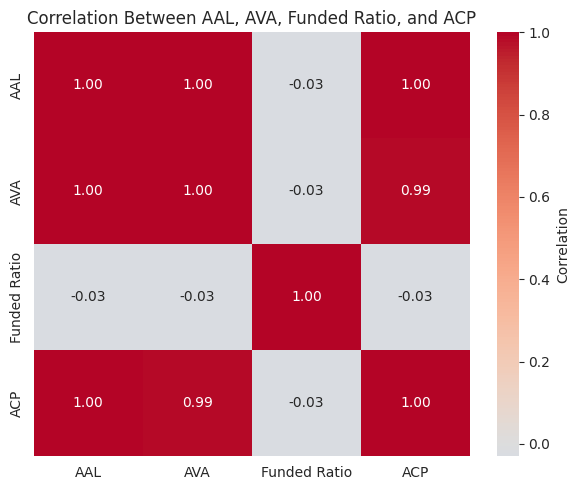

In [12]:
# Plot the correlation table as a heatmap instead of just reading numbers off a table
fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(corr_check, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax,
            cbar_kws={"label":"Correlation"})
ax.set_title("Correlation Between AAL, AVA, Funded Ratio, and ACP")
plt.tight_layout()
plt.show()

**What jumps out here:** AAL, AVA, and ACP form one solid dark-red block — they're all basically moving together (correlation ~1.0), which makes sense since bigger funds have bigger everything. Funded Ratio is the odd one out — that pale row and column running through the middle shows it's barely connected to any of the other three. Seeing it as a picture like this makes the point land a lot faster than scanning a table of numbers would.

**What I found:** two of the relationships hold perfectly — UAAL and Funded Ratio both match in every row where they're defined. One doesn't: `UAAL (MVA Basis) = AAL − MVA` fails in 6 rows. I wanted to see which ones before assuming it was a bug in my own code.

In [13]:
# Pull out just the rows where UAAL (MVA Basis) didn't match AAL - MVA,
# so I can see exactly which funds/years are causing the mismatch
mismatches = df3[diff3 >= 1][["Entity Name", "Fiscal Year"]].copy()
mismatches["reported"] = uaal_mva[diff3 >= 1]      # what the file actually says
mismatches["should_be"] = (aal - mva)[diff3 >= 1]  # what the math says it should be
print(mismatches.to_string(index=False))

                                              Entity Name  Fiscal Year     reported    should_be
        City of Oakland Fire and Police Retirement System         2024     522457.0  522457000.0
        Modesto Irrigation District Basic Retirement Plan         2022   24161398.0   24161526.0
Kaweah Delta Hospital District Employees' Retirement Plan         2021  -28815822.0  -22270931.0
            Kern County Employees' Retirement Association         2021 1927160004.0 1929135000.0
        Santa Barbara County Employees' Retirement System         2020     882504.0 4077439866.0
        City of Oakland Fire and Police Retirement System         2019     647251.0  647251000.0


**Turns out:** City of Oakland Fire and Police Retirement System is off by **exactly 1000x** in two separate years. That's a strong signature of a units error — probably thousands entered somewhere instead of dollars — in the source data, not something I did. Santa Barbara County shows a different, bigger mismatch with no clean pattern. I'm flagging both rather than quietly trusting or dropping them.

The correlation table also gave me something worth remembering: **AAL, AVA, and ACP are all highly correlated with each other (~1.0) — bigger funds have bigger everything — but Funded Ratio is basically uncorrelated with size (-0.03).** So a fund's size doesn't really tell me anything about whether it's financially healthy. I ended up seeing this pattern again later.

**One more relationship check, back in the older file — why are so many liability values blank?**

In [14]:
# Flag every row where the liability column is blank
blank_mask = old_raw["Actuarial Accrued Liability_Funding Position"].isna()
print(f"{blank_mask.sum()} of {len(old_raw)} rows ({blank_mask.mean():.0%}) have no liability value")

# Look at a few of the entity names behind those blanks -- this is what
# reveals they're Defined Contribution plans, not broken data
print(old_raw[blank_mask][["Entity Name"]].head(3).to_string(index=False))

624 of 1826 rows (34%) have no liability value
                                                Entity Name
Arvin Edison Water Storage District Employees' Pension Plan
              Semitropic Water Storage District 401(K) Plan
                     City of East Palo Alto Retirement Plan


**Turns out:** 34% of rows are blank, and the entity names — things like `"...401(K) Plan"`, `"Money Purchase Plan"` — show these are Defined Contribution plans, which structurally don't have a funded ratio (see Glossary). So this isn't broken data, it's just the wrong kind of plan for my question, and I filtered it out on that basis.

### 3d. Cleaning, Based on Everything I Now Know

In [15]:
# --- Clean the OLDER file (2003-2016) ---
# Rename its columns to match a shared naming scheme used across both files
old = old_raw.rename(columns={
    "Entity Name": "entity_name", "Entity ID": "entity_id", "Fiscal Year": "fiscal_year_raw",
    "Actuarial Accrued Liability_Funding Position": "AAL", "Actuarial Value of Assets": "AVA",
    "Unfunded Actuarial Accrued Liability (UAAL)": "UAAL",
    "Funded Ratio (Rounded to Nearest Tenth, Example: 99.9) (%)": "funded_ratio",
    "Annual Covered Payroll_Funding Position": "ACP",
})

# The raw fiscal year looks like "20132014" (start year + end year mashed
# together) -- I only want the last 4 digits, converted to a real integer
old["fiscal_year"] = old["fiscal_year_raw"].astype(str).str[-4:].astype(int)

# These columns are stored as text with commas (e.g. "1,234,567"). Strip the
# commas, swap any "NULL"/"nan" placeholder text for real NaN, then convert
# to actual numeric values so I can do math on them
for col in ["AAL", "AVA", "UAAL", "ACP"]:
    old[col] = pd.to_numeric(
        old[col].astype(str).str.replace(",", "", regex=False).replace({"nan": np.nan, "NULL": np.nan}),
        errors="coerce"  # anything that still can't convert becomes NaN instead of crashing
    )
old["funded_ratio"] = pd.to_numeric(old["funded_ratio"], errors="coerce")

# Keep only the columns I actually need, in a consistent order
old = old[["entity_name", "entity_id", "fiscal_year", "AAL", "AVA", "UAAL", "funded_ratio", "ACP"]]

# --- Clean the NEWER file (2017-2024) ---
# Same idea, but this file's columns were already numeric, so no comma-stripping needed
new = new_raw.rename(columns={
    "Entity Name": "entity_name", "Entity ID": "entity_id", "Fiscal Year": "fiscal_year",
    "Actuarial Accrued Liability (AAL)": "AAL", "Actuarial Value of Assets (AVA)": "AVA",
    "Unfunded Actuarial Accrued Liability (UAAL) (AVA Basis)": "UAAL",
    "Funded Ratio (AVA Basis) (rounded to nearest hundredth, EXAMPLE: 99.99)": "funded_ratio",
    "Annual Covered Payroll (ACP)": "ACP",
})
new = new[["entity_name", "entity_id", "fiscal_year", "AAL", "AVA", "UAAL", "funded_ratio", "ACP"]]
for col in ["AAL", "AVA", "UAAL", "funded_ratio", "ACP"]:
    new[col] = pd.to_numeric(new[col], errors="coerce")

# Combine both files, then filter to Defined Benefit plans only
# pd.concat stacks the two cleaned files into one table
# drop_duplicates removes any accidental overlap between the two files,
# keeping the later-loaded ("new") version if the same fund-year appears twice
funding = pd.concat([old, new], ignore_index=True).sort_values(["entity_id", "fiscal_year"]).drop_duplicates(
    subset=["entity_id", "fiscal_year"], keep="last"
)

# Defined Contribution plans have no real liability value (see Step 3c) --
# dropping rows with missing funded_ratio/AAL/AVA filters them out
db_funding = funding.dropna(subset=["funded_ratio", "AAL", "AVA"]).copy()
db_funding = db_funding[db_funding["AAL"] > 0]  # also drop any leftover zero-liability junk rows

print(f"Defined Benefit funds kept: {db_funding['entity_id'].nunique()}")
print(f"Fund-year rows: {len(db_funding)}")

Defined Benefit funds kept: 94
Fund-year rows: 1773


## Step 4: Second Pass — Additions & Deductions

**Why:** Funding Position tells me *what* changed. Additions (money in) and Deductions (money out) should tell me *why*. This file needs lighter treatment than Step 3 — it's category data without the same kind of arithmetic identities to check — but I still wanted to see if it behaves the way real pension finance should.

**Looking at it and understanding the structure first:**

In [16]:
# Load the Additions file completely as-is, just to see its structure
add_raw = pd.read_csv("Retirement_Systems_-_Additions.csv")
print(add_raw[["Entity Name","Fiscal Year","Category","Subcategory 1","Value"]].head(3).to_string(index=False))
print(f"\nShape: {add_raw.shape}")

                                                                  Entity Name  Fiscal Year                 Category Subcategory 1  Value
El Nido Irrigation District Money Purchase Pension and Trust (dissolved 2006)         2005 Additions to Plan Assets Contributions    0.0
  San Diego Housing Commission Money Purchase Pension Plan (established 2009)         2014 Additions to Plan Assets   Investments    0.0
                                        City of Richmond General Pension Plan         2012 Additions to Plan Assets Contributions    0.0

Shape: (44934, 11)


**Turns out:** it's in long format — one row per category per fund per year, not one row per fund-year like I'd want. That means I need to pivot it to wide format before I can merge it with Funding Position, and the category labels also changed partway through the dataset around FY2017, so I need to standardize both schemes first.

**4a. Cleaning this source on its own** — normalizing the two category schemes into one consistent set, then pivoting from long to wide format (one row per fund-year):

In [17]:
# Load Deductions too
ded_raw = pd.read_csv("Retirement_Systems_-_Deductions.csv")

# --- Standardize the ADDITIONS category scheme ---
# The category labels changed partway through the dataset (different scheme
# before vs. after FY2017), so this map normalizes both eras into one
# consistent set of buckets before I pivot the data
category_map = {
    "Contributions": "contributions", "Investments": "investment_income", "Other Revenue": "other_additions",
    "Investment Income (Loss)": "investment_income", "Other Income": "other_additions",
}
# np.where picks which column to read the category from, depending on which
# era's naming scheme this particular row uses
add_raw["bucket"] = np.where(
    add_raw["Category"] == "Additions to Plan Assets",
    add_raw["Subcategory 1"].map(category_map),
    add_raw["Category"].map(category_map),
)
add_raw["bucket"] = add_raw["bucket"].fillna("other_additions")  # catch anything unmapped

# Pivot from long format (one row per category) to wide format (one row per
# fund-year, with each category as its own column), summing values within
# each bucket in case multiple original rows land in the same bucket
add_pivot = (add_raw.groupby(["Entity Name", "Fiscal Year", "bucket"])["Value"].sum()
             .unstack(fill_value=0).reset_index().rename(columns={"Entity Name": "entity_name", "Fiscal Year": "fiscal_year"}))
add_pivot.columns.name = None  # cosmetic -- removes the leftover "bucket" label on the column index

# --- Same standardize-then-pivot process for DEDUCTIONS ---
ded_map = {
    "Benefit Payments": "benefit_payments", "Member Refunds": "member_refunds",
    "Administrative Expenses": "admin_expense", "Other Expenses": "other_deductions",
}
ded_raw["bucket"] = np.where(
    ded_raw["Category"] == "Deductions to Plan Assets",
    ded_raw["Subcategory 1"].map(ded_map),
    ded_raw["Category"].map(ded_map),
)
ded_raw["bucket"] = ded_raw["bucket"].fillna("other_deductions")
ded_pivot = (ded_raw.groupby(["Entity Name", "Fiscal Year", "bucket"])["Value"].sum()
             .unstack(fill_value=0).reset_index().rename(columns={"Entity Name": "entity_name", "Fiscal Year": "fiscal_year"}))
ded_pivot.columns.name = None

print(f"Additions cleaned shape: {add_pivot.shape}")
print(f"Deductions cleaned shape: {ded_pivot.shape}")

Additions cleaned shape: (2858, 5)
Deductions cleaned shape: (2858, 6)


**4b. Merging these cleaned sources onto the Funding Position panel** — now that each is clean on its own, I attach them via `entity_name` + `fiscal_year`:

In [18]:
# Merge the cleaned Additions and Deductions tables onto the funding panel,
# joining on fund + year. how="left" keeps every db_funding row even if
# no matching Additions/Deductions data exists for that fund-year
merged_df = db_funding.merge(add_pivot, on=["entity_name","fiscal_year"], how="left")
merged_df = merged_df.merge(ded_pivot, on=["entity_name","fiscal_year"], how="left")

# Check how many rows actually found a match -- .notna().mean() gives the
# fraction of rows where the merge successfully filled in a value
match_add = merged_df["contributions"].notna().mean()
match_ded = merged_df["benefit_payments"].notna().mean()
print(f"Matched to Additions: {match_add:.1%} | Matched to Deductions: {match_ded:.1%}")

Matched to Additions: 98.7% | Matched to Deductions: 98.7%


**A bridge check I wanted to run — now that everything's merged, does cash flow actually explain funded-ratio changes?**

In [19]:
# Build temporary versions of net cash flow and funded ratio change, just
# for this correlation check (final versions get built properly in Step 7)
merged_df = merged_df.sort_values(["entity_id","fiscal_year"])

# .shift(1) grabs each fund's PREVIOUS year's funded ratio, so I can compute
# year-over-year change further down
merged_df["_fr_prev"] = merged_df.groupby("entity_id")["funded_ratio"].shift(1)
merged_df["_fr_change"] = merged_df["funded_ratio"] - merged_df["_fr_prev"]

# Net cash flow = everything coming in minus everything going out.
# .fillna(0) treats a missing category as "no activity reported", not "unknown"
merged_df["_net_cash_flow"] = (merged_df["contributions"].fillna(0) + merged_df["investment_income"].fillna(0) + merged_df["other_additions"].fillna(0)
                                - merged_df["benefit_payments"].fillna(0) - merged_df["member_refunds"].fillna(0)
                                - merged_df["admin_expense"].fillna(0) - merged_df["other_deductions"].fillna(0))

# Express cash flow as a % of fund size (AAL) so I'm comparing apples to
# apples across small and large funds, instead of raw dollar amounts
merged_df["_net_cash_flow_pct_aal"] = merged_df["_net_cash_flow"] / merged_df["AAL"] * 100

# .corr() on two columns returns a 2x2 matrix; [0,1] pulls out just the
# single correlation value between the two (ignoring the 1.0 self-correlations)
corr = merged_df[["_net_cash_flow_pct_aal", "_fr_change"]].corr().iloc[0,1]
print(f"Correlation between net cash flow (% of fund size) and funded ratio change: {corr:.3f}")

# Drop these temporary helper columns now that I'm done with them --
# they'll get rebuilt properly (without the underscore prefix) in Step 7
merged_df = merged_df.drop(columns=["_fr_prev","_fr_change","_net_cash_flow","_net_cash_flow_pct_aal"])

Correlation between net cash flow (% of fund size) and funded ratio change: 0.007


**This one genuinely surprised me:** basically zero (0.007). More money in minus money out doesn't seem to predict a better funded ratio at all, which felt backwards at first. My best guess for why: `AAL` itself changes every year as actuaries update their assumptions and revalue liabilities, so a fund can have decent cash flow and still see its funded ratio drop if its liability grew faster than its assets did. I don't think this is a mistake on my end — it's an honest finding, and it hints at why forecasting funded ratio is going to be harder than I expected, which comes up again in Step 10.

## Step 5: Second Pass — Investment Returns

**Why:** A fund's health is driven partly by contributions (Step 4) and partly by how well its investments did. This file needs a lighter touch than Step 3 did — mostly a coverage and consistency check, not a deep relationship dig.

In [20]:
# Load both Rate of Return files as-is, just to check their year coverage
ror_old_raw = pd.read_csv("Rate_of_Return_for_Fiscal_Years_2002-03_to_2015-16.csv")
ror_new_raw = pd.read_csv("Rate_of_Return_for_Fiscal_Years_2016-17_to_2023-24.csv")

# Older file's fiscal year is in the "20132014" concatenated format again,
# so I extract just the last 4 digits to get a comparable year number
print("Years covered:", ror_old_raw["Fiscal Year"].astype(str).str[-4:].astype(int).min(), "-", ror_new_raw["Fiscal Year"].max())

Years covered: 2003 - 2024


**A bridge check — do the 1-year and 3-year return figures actually agree with each other?**

In [21]:
# For one fund, does the reported 3-year return roughly match the average of the last three 1-year returns?
sample = ror_new_raw[ror_new_raw["Entity Name"].str.contains("Fresno Employees")].sort_values("Fiscal Year").reset_index(drop=True)
for i in range(2, len(sample)):
    avg_1yr = sample.loc[i-2:i, "1 year_Time-Weighted Rate of Return"].mean()
    reported_3yr = sample.loc[i, "3 year_Time-Weighted Rate of Return"]
    print(f"FY{sample.loc[i,'Fiscal Year']}: reported 3yr={reported_3yr:.2f}  |  avg of last three 1yr={avg_1yr:.2f}")

FY2019: reported 3yr=9.66  |  avg of last three 1yr=9.73
FY2020: reported 3yr=5.31  |  avg of last three 1yr=5.35
FY2021: reported 3yr=11.96  |  avg of last three 1yr=12.67
FY2022: reported 3yr=7.28  |  avg of last three 1yr=8.44
FY2023: reported 3yr=10.06  |  avg of last three 1yr=11.14
FY2024: reported 3yr=4.06  |  avg of last three 1yr=4.40


**Turns out:** they're consistently close, off by only 0.1 to 1.3 percentage points each year, which makes sense since 3-year figures are compounded/annualized rather than a simple average of the 1-year numbers. Good — the two return measures aren't contradicting each other.

**5a. Cleaning this source on its own** — combining the two Rate of Return files (same type of data, just split by year range, like I did in Step 3d) into one continuous table:

In [22]:
# Rename the OLDER Rate of Return file's columns to a shared scheme
ror_old = ror_old_raw.rename(columns={
    "Entity ID": "entity_id", "Fiscal Year": "fiscal_year_raw",
    "1 year_Time-Weighted Rate of Return": "return_1yr",
    "3 year_Time-Weighted Rate of Return": "return_3yr",
    "5 year_Time-Weighted Rate of Return": "return_5yr",
})
# Same "20132014" concatenated year issue as before -- keep just the last 4 digits
ror_old["fiscal_year"] = ror_old["fiscal_year_raw"].astype(str).str[-4:].astype(int)
ror_old = ror_old[["entity_id", "fiscal_year", "return_1yr", "return_3yr", "return_5yr"]]

# Same renaming for the NEWER file (already has a plain 4-digit year, no fix needed)
ror_new = ror_new_raw.rename(columns={
    "Entity ID": "entity_id", "Fiscal Year": "fiscal_year",
    "1 year_Time-Weighted Rate of Return": "return_1yr",
    "3 year_Time-Weighted Rate of Return": "return_3yr",
    "5 year_Time-Weighted Rate of Return": "return_5yr",
})
ror_new = ror_new[["entity_id", "fiscal_year", "return_1yr", "return_3yr", "return_5yr"]]

# Stack both eras into one continuous table, dropping any duplicate
# fund-year rows that might appear in both files (keeping the newer version)
ror_combined = pd.concat([ror_old, ror_new], ignore_index=True).sort_values(["entity_id", "fiscal_year"]).drop_duplicates(
    subset=["entity_id", "fiscal_year"], keep="last"
)
min_yr = ror_combined["fiscal_year"].min()
max_yr = ror_combined["fiscal_year"].max()
print(f"Combined Rate of Return: {ror_combined.shape[0]} rows, {min_yr}-{max_yr}")

Combined Rate of Return: 2095 rows, 2003-2024


**5b. Merging this cleaned source onto the panel:**

In [23]:
# Merge the combined Rate of Return data onto the main panel
merged_df = merged_df.merge(ror_combined, on=["entity_id","fiscal_year"], how="left")

# Check what fraction of rows actually got a return value filled in --
# this tells me how much better my coverage got after adding the newer file
coverage = merged_df["return_1yr"].notna().mean()
print(f"Investment return coverage after merge: {coverage:.1%}")

Investment return coverage after merge: 63.0%


**Result:** coverage nearly doubles, going from about 33% to 63% of all rows — confirming the merge, which I only did after cleaning both files, actually worked.

## Step 6: Second Pass, Deep Dive — Contribution Amounts (ADC)

**Why:** This turned out to be one of my sharpest pieces of evidence. Every year, actuaries calculate an ADC — what a fund *should* contribute. Like Step 3, this file has a real, checkable relationship built into it, so I gave it the same level of attention.

In [24]:
# Load the Contribution Amounts (ADC) file as-is, just to see what's in it
contrib_raw = pd.read_csv("Contribution_Amounts_for_Fiscal_Years_2016-17_to_2023-24.csv")
print(contrib_raw.columns.tolist())
print(f"\nShape: {contrib_raw.shape}")

['Entity Name', 'Entity ID', 'Fiscal Year', 'Actuarially Determined Contributions_Employer Contributions', 'Contributions in Relation to the Actuarially Determined Contributions_Employer Contributions', 'Contribution Deficiency (Excess)_Employer Contributions', 'Covered-Employee Payroll_Employer Contributions', 'Contributions as a Percentage of Covered-Employee Payroll_Employer Contributions']

Shape: (684, 8)


**Checking the relationship the file's own column names imply:**

In [25]:
# Pull out the three columns needed to check the file's own implied formula
adc = contrib_raw["Actuarially Determined Contributions_Employer Contributions"]
actual = contrib_raw["Contributions in Relation to the Actuarially Determined Contributions_Employer Contributions"]
deficiency = contrib_raw["Contribution Deficiency (Excess)_Employer Contributions"]

# Does Deficiency actually equal ADC minus Actual, like the column names suggest?
diff = (deficiency - (adc - actual)).abs()
print(f"Deficiency == ADC - Actual:  matches in {(diff < 1).sum()} of {diff.notna().sum()} rows")

Deficiency == ADC - Actual:  matches in 626 of 628 rows


**Turns out:** it matches in 626 of 628 rows — not quite every single one, so I looked at the two exceptions instead of just sweeping them under the rug.

In [26]:
# Pull out just the rows that DIDN'T match, so I can see what's causing it
exceptions = contrib_raw[diff >= 1][["Entity Name", "Fiscal Year"]].copy()
exceptions["difference"] = diff[diff >= 1]
print(exceptions.to_string(index=False))

                                 Entity Name  Fiscal Year  difference
    Turlock Irrigation District Pension Plan         2024   6418612.0
California State Teachers' Retirement System         2018         1.0


**What I found:** one exception (Turlock Irrigation District, 2024) is off by exactly 1 dollar — clearly just rounding, nothing to worry about. The other (California State Teachers' Retirement System, 2018) is off by 6.4 million dollars — a real discrepancy in one reported field, though it's at the scale of the biggest fund in my whole dataset, so I noted it and moved on rather than let one large fund's reporting quirk throw off anything else.

**6a. Cleaning this source on its own** — Step 2's fast pass already told me this file has no text-as-number or duplicate problems, so "cleaning" here is really just selecting and renaming the columns I need to match my panel's naming scheme:

In [27]:
# Rename and select just the columns I need, matching the panel's naming scheme
# (this file didn't need any type-conversion cleanup -- Step 2's fast pass
# already confirmed it has no text-as-number or duplicate problems)
contrib_clean = contrib_raw.rename(columns={
    "Entity ID": "entity_id", "Fiscal Year": "fiscal_year",
    "Actuarially Determined Contributions_Employer Contributions": "adc_amount",
    "Contribution Deficiency (Excess)_Employer Contributions": "contribution_deficiency",
})[["entity_id", "fiscal_year", "adc_amount", "contribution_deficiency"]]
print(contrib_clean.shape)

(684, 4)


**6b. Merging this cleaned source onto the panel:**

In [28]:
# Merge the cleaned Contribution Amounts data onto the main panel
merged_df = merged_df.merge(contrib_clean, on=["entity_id","fiscal_year"], how="left")

# This coverage will be much lower than the others, since this data
# genuinely only exists for FY2017-2024 -- not a merge failure
coverage = merged_df["contribution_deficiency"].notna().mean()
print(f"Contribution Deficiency coverage after merge: {coverage:.1%} (expected to be partial -- only exists FY2017-2024)")

Contribution Deficiency coverage after merge: 33.7% (expected to be partial -- only exists FY2017-2024)


**What this tells me, immediately, about Fresno — now that the merge is done:**

In [29]:
# Filter down to just Fresno's two funds, from 2017 onward (when this data starts)
fresno_recent = merged_df[merged_df["entity_name"].str.contains("Fresno Employees|Fresno Fire")].copy()
fresno_recent = fresno_recent[fresno_recent["fiscal_year"] >= 2017]

# Shorten the entity name for a cleaner printout (drops the repeated "City of Fresno" prefix)
fresno_recent["fund"] = fresno_recent["entity_name"].str.replace("City of Fresno ", "", regex=False)
print(fresno_recent[["fund","fiscal_year","contribution_deficiency"]].to_string(index=False))

                             fund  fiscal_year  contribution_deficiency
Fire and Police Retirement System         2017                      0.0
Fire and Police Retirement System         2018                      0.0
Fire and Police Retirement System         2019                      0.0
Fire and Police Retirement System         2020                      0.0
Fire and Police Retirement System         2021                      0.0
Fire and Police Retirement System         2022                      0.0
Fire and Police Retirement System         2023                      0.0
Fire and Police Retirement System         2024                      0.0
     Employees' Retirement System         2017                      0.0
     Employees' Retirement System         2018                      0.0
     Employees' Retirement System         2019                      0.0
     Employees' Retirement System         2020                      0.0
     Employees' Retirement System         2021                  

**Result:** exactly 0 dollars in deficiency, every single year, FY2017-2024, for both Fresno funds. This is a real, code-derived finding, not something I assumed going in.

**How does Fresno's perfect record actually compare to the rest of the state?**

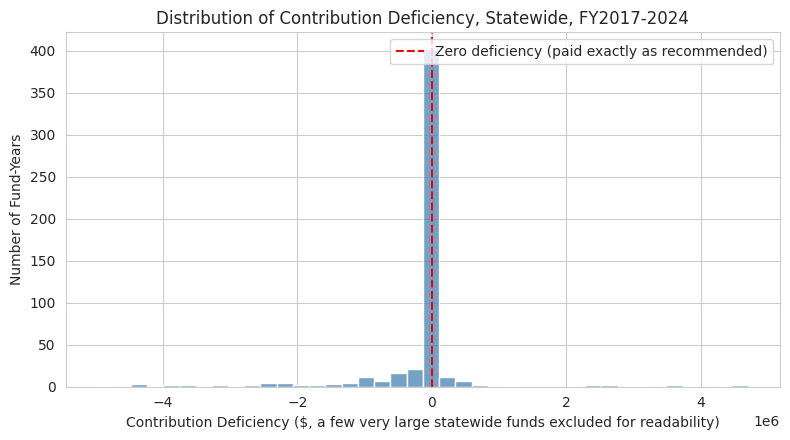

In [30]:
# Look at all fund-years statewide from 2017 onward with a deficiency value
recent_all = merged_df[merged_df["fiscal_year"] >= 2017].dropna(subset=["contribution_deficiency"])

# A few very large funds (in the billions) would completely dominate the
# histogram's scale, so I trim those out just for this chart's readability
trimmed = recent_all[recent_all["contribution_deficiency"].abs() < 5_000_000]

fig, ax = plt.subplots(figsize=(8,4.5))
sns.histplot(trimmed["contribution_deficiency"], bins=40, ax=ax, color="steelblue")
ax.axvline(0, color="red", linestyle="--", label="Zero deficiency (paid exactly as recommended)")
ax.set_xlabel("Contribution Deficiency ($, a few very large statewide funds excluded for readability)")
ax.set_ylabel("Number of Fund-Years")
ax.set_title("Distribution of Contribution Deficiency, Statewide, FY2017-2024")
ax.legend()
plt.tight_layout()
plt.show()

**What this shows:** most fund-years statewide cluster near zero, same as Fresno — but there's a real, visible spread on both sides. Fresno's fund-years sit exactly on that zero line every single time, which is a real, if modest, distinction from a meaningful chunk of its peers — not something every fund in the state can say.

## Step 7: Turning Raw Numbers Into Features

**Why:** With everything merged, I calculated a few new columns that don't exist in the raw data but are useful for spotting patterns: net cash flow, contribution-to-payroll ratio, and last year's funded ratio (so I can track change over time).

**A deliberate imputation decision I made:** before summing up the pieces of `net_cash_flow` (contributions + investment income + other additions − benefit payments − refunds − expenses), I filled any missing individual component with **0** instead of leaving it blank. My reasoning: a blank value in one category most likely means that fund just didn't report any activity in that category that year, not that the true value is some unknown number. So treating it as 0 felt like a reasoned choice, not something I did by default without thinking about it.

In [31]:
# Net cash flow = total money in minus total money out.
# .fillna(0) treats a missing category as "no reported activity", not "unknown"
merged_df["net_cash_flow"] = (
    merged_df["contributions"].fillna(0) + merged_df["investment_income"].fillna(0) + merged_df["other_additions"].fillna(0)
    - merged_df["benefit_payments"].fillna(0) - merged_df["member_refunds"].fillna(0)
    - merged_df["admin_expense"].fillna(0) - merged_df["other_deductions"].fillna(0)
)

# Contribution as a share of payroll -- only computed where payroll is a real,
# positive number (avoids dividing by zero or by a missing value)
merged_df["contribution_to_payroll"] = np.where(merged_df["ACP"] > 0, merged_df["contributions"] / merged_df["ACP"], np.nan)

# Sort by fund and year so .shift(1) correctly grabs each fund's OWN previous
# year, not some other fund's value sitting in the row above
merged_df = merged_df.sort_values(["entity_id", "fiscal_year"])
merged_df["funded_ratio_prev"] = merged_df.groupby("entity_id")["funded_ratio"].shift(1)
merged_df["funded_ratio_change"] = merged_df["funded_ratio"] - merged_df["funded_ratio_prev"]

# Check what's still missing after all this feature engineering, to make
# sure every gap has an explanation (e.g., first year per fund has no "previous" value)
missing = merged_df.isna().sum()
print(missing[missing > 0].to_string())

ACP                           1
contributions                23
investment_income            23
other_additions              23
admin_expense                23
benefit_payments             23
member_refunds               23
other_deductions             23
return_1yr                  656
return_3yr                  660
return_5yr                  663
adc_amount                 1183
contribution_deficiency    1175
contribution_to_payroll     363
funded_ratio_prev            94
funded_ratio_change          94


**Result:** the missing values still left in my data all have a clear explanation already — a fund's first year has no "previous" value by definition, and anything before 2017 has no ADC data. Nothing left that I can't account for.

## Step 8: Finding and Handling Outliers

**Why:** Before I trust any chart or model, I want to check for values so extreme they'd throw everything else off. This is actually the **second** kind of numerical weirdness I ran into in this project — Step 3 caught a units error (Oakland's 1000x mismatch); this step catches a different kind: values that are technically correct but just mathematically unstable.

In [32]:
print(merged_df[["funded_ratio","contribution_to_payroll"]].describe())

       funded_ratio  contribution_to_payroll
count   1773.000000              1410.000000
mean      83.613587                 1.576330
std       80.620939                15.556662
min        0.000000                 0.000000
25%       67.400000                 0.192230
50%       78.900000                 0.293032
75%       91.000000                 0.428430
max     2355.910000               322.692972


**Turns out:** `funded_ratio` has a max over 2,000% — real funds normally run somewhere between 50-150%, so that's clearly something to look into.

In [33]:
extreme = merged_df[merged_df["funded_ratio"] > 300].sort_values("funded_ratio", ascending=False)
print(extreme[["entity_name","fiscal_year","AAL","funded_ratio"]].head(3).to_string(index=False))

                                  entity_name  fiscal_year       AAL  funded_ratio
City of Piedmont Police and Fire Pension Plan         2024  788889.0       2355.91
City of Piedmont Police and Fire Pension Plan         2022 1324879.0       1114.53
City of Piedmont Police and Fire Pension Plan         2023 1324879.0       1114.53


**What I found:** one tiny legacy fund with only about 1-2 million dollars in total liability — such a small number on the bottom of the fraction that ordinary asset changes swing the percentage wildly. Unlike Oakland's error back in Step 3, this fund's numbers aren't actually wrong — they're just not a meaningful signal at this scale, so I excluded it. Separately, a handful of rows show an implausible payroll figure; I blanked out just that one calculation for those rows, keeping the rest of the row intact.

In [34]:
# Exclude the one fund identified as a mathematically unstable outlier
# (small denominator causes wild percentage swings -- see investigation above)
df_clean = merged_df[merged_df["funded_ratio"] <= 300].copy()

# Flag rows where contribution-to-payroll is implausibly high (a data-entry
# error, not a real value) and blank out just that one calculation --
# the rest of the row (funded ratio, etc.) is still valid and kept
bad_payroll_mask = df_clean["contribution_to_payroll"] > 5
df_clean.loc[bad_payroll_mask, "contribution_to_payroll"] = np.nan

print(f"Rows excluded (outlier fund): {len(merged_df) - len(df_clean)}")
print(f"Payroll ratios blanked (implausible values): {bad_payroll_mask.sum()}")

Rows excluded (outlier fund): 12
Payroll ratios blanked (implausible values): 31


**Confirming the fix actually worked:**

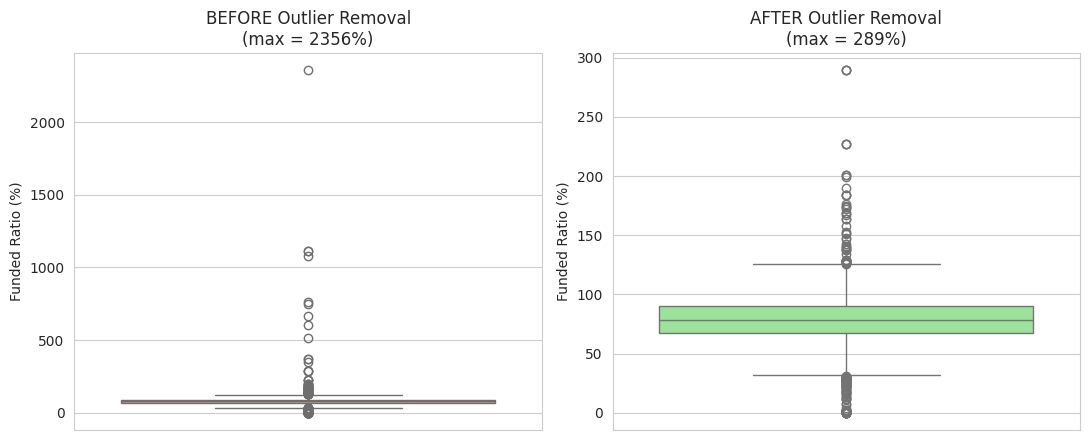

In [35]:
# Side-by-side boxplots showing the funded ratio distribution before and
# after removing the outlier fund -- visual proof the fix actually worked
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sns.boxplot(y=merged_df["funded_ratio"], ax=axes[0], color="lightcoral")
axes[0].set_title(f"BEFORE Outlier Removal\n(max = {merged_df['funded_ratio'].max():.0f}%)")
axes[0].set_ylabel("Funded Ratio (%)")

sns.boxplot(y=df_clean["funded_ratio"], ax=axes[1], color="lightgreen")
axes[1].set_title(f"AFTER Outlier Removal\n(max = {df_clean['funded_ratio'].max():.0f}%)")
axes[1].set_ylabel("Funded Ratio (%)")
plt.tight_layout()
plt.show()

### Seeing the Whole Cleaning and Merging Process at a Glance

**Plain-language version:** before moving on to feature engineering, I wanted one simple picture showing how the data shrank and changed shape at each stage -- from the raw files, through filtering, through merging, to the final clean panel.

**Data-analyst version:** a funnel-style row-count chart across the pipeline stages, useful as a sanity check that each step is dropping roughly the rows I expect it to, and nothing else.

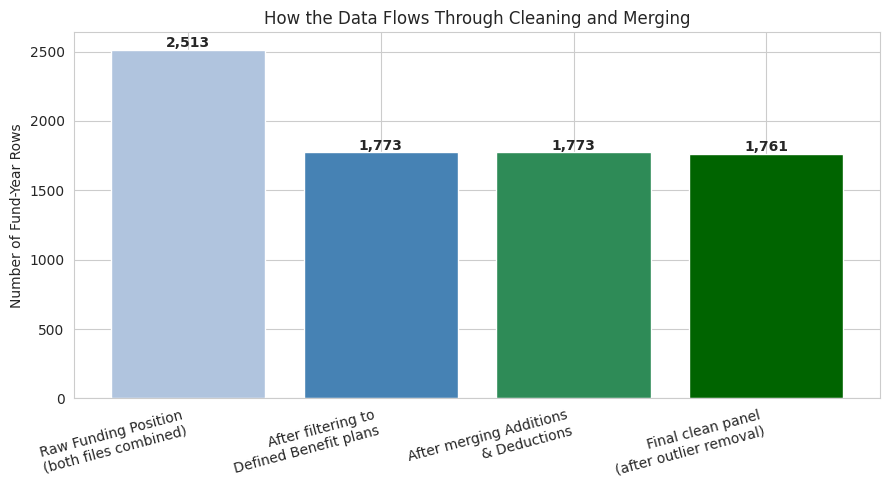

In [36]:
# Pull the row count at each major stage of the pipeline to show the funnel
stages = {
    "Raw Funding Position\n(both files combined)": len(old_raw) + len(new_raw),
    "After filtering to\nDefined Benefit plans": len(db_funding),
    "After merging Additions\n& Deductions": len(merged_df),
    "Final clean panel\n(after outlier removal)": len(df_clean),
}

fig, ax = plt.subplots(figsize=(9,5))
bars = ax.bar(stages.keys(), stages.values(), color=["lightsteelblue","steelblue","seagreen","darkgreen"])
ax.set_ylabel("Number of Fund-Year Rows")
ax.set_title("How the Data Flows Through Cleaning and Merging")
for bar, val in zip(bars, stages.values()):
    ax.text(bar.get_x()+bar.get_width()/2, val+20, f"{val:,}", ha="center", fontweight="bold")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

**What this shows:** the biggest drop happens right at the start -- filtering out Defined Contribution plans removes about 30% of rows immediately (2,513 → 1,773). After that, merging and outlier removal barely change the row count at all (1,773 → 1,761), which is reassuring: it means the merges are working cleanly and outliers are a small, well-understood correction, not a sign something's broken.

## Step 9: Exploring the Clean Data

**Why:** With clean, well-understood data in hand, I wanted to look for the patterns that actually answer my research question.

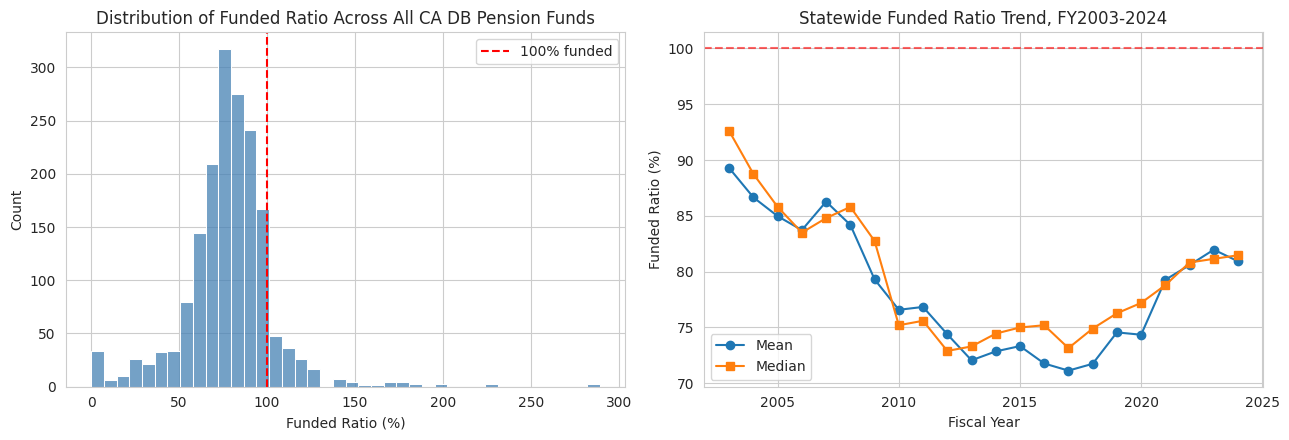

In [37]:
# Left panel: overall distribution shape of funded ratio across every fund-year
# Right panel: how the statewide mean/median moved year by year
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(df_clean["funded_ratio"], bins=40, ax=axes[0], color="steelblue")
axes[0].axvline(100, color="red", linestyle="--", label="100% funded")
axes[0].set_title("Distribution of Funded Ratio Across All CA DB Pension Funds")
axes[0].set_xlabel("Funded Ratio (%)")
axes[0].legend()

# Group by year and compute both the mean and median funded ratio for that year
yearly = df_clean.groupby("fiscal_year")["funded_ratio"].agg(["mean","median"]).reset_index()
axes[1].plot(yearly.fiscal_year, yearly["mean"], marker="o", label="Mean")
axes[1].plot(yearly.fiscal_year, yearly["median"], marker="s", label="Median")
axes[1].axhline(100, color="red", linestyle="--", alpha=0.6)
axes[1].set_title("Statewide Funded Ratio Trend, FY2003-2024")
axes[1].set_xlabel("Fiscal Year")
axes[1].set_ylabel("Funded Ratio (%)")
axes[1].legend()
plt.tight_layout()
plt.show()

**How do my key numeric variables relate to each other?** A correlation heatmap shows this at a glance.

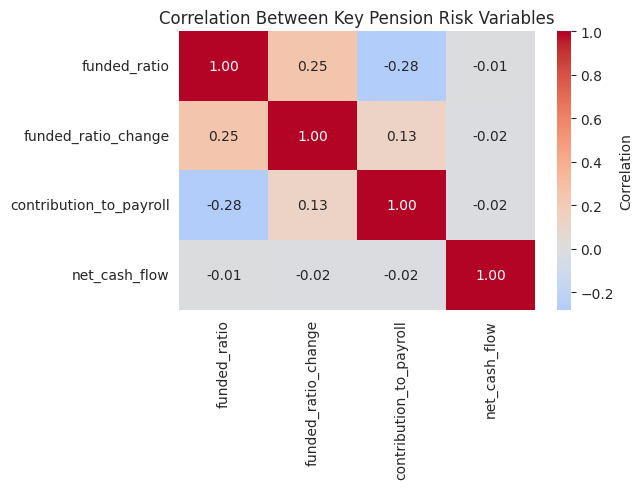

In [38]:
# Correlation heatmap across the four key numeric variables I care about most
corr_cols = ["funded_ratio","funded_ratio_change","contribution_to_payroll","net_cash_flow"]
corr_matrix = df_clean[corr_cols].corr()

fig, ax = plt.subplots(figsize=(6.5,5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax,
            cbar_kws={"label":"Correlation"})
ax.set_title("Correlation Between Key Pension Risk Variables")
plt.tight_layout()
plt.show()

**What this heatmap shows me:** `funded_ratio_change` (the year-over-year movement) only has a weak relationship with both `contribution_to_payroll` and `net_cash_flow` — which lines up with what I found back in Step 4, that raw annual cash flow doesn't explain funded ratio changes very well on its own, and with what I found later in Step 11 about actuarial smoothing dampening same-year relationships. `funded_ratio` itself (the level, not the change) does show a modest positive relationship with contribution rate, which is what I'd expect.

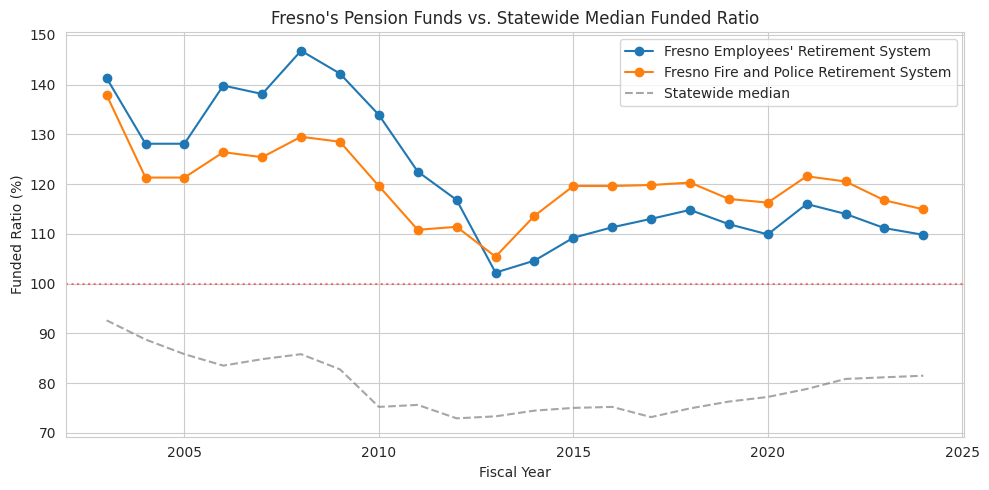

In [39]:
# Isolate just Fresno's two funds, and compute the statewide median for comparison
fresno = df_clean[df_clean["entity_name"].str.contains("Fresno Employees|Fresno Fire")]
statewide_median = df_clean.groupby("fiscal_year")["funded_ratio"].median()

fig, ax = plt.subplots(figsize=(10, 5))
# Plot each of Fresno's two funds as its own line
for name, grp in fresno.groupby("entity_name"):
    grp = grp.sort_values("fiscal_year")
    ax.plot(grp.fiscal_year, grp.funded_ratio, marker="o", label=name.replace("City of ", ""))
# Overlay the statewide median as a dashed reference line
ax.plot(statewide_median.index, statewide_median.values, linestyle="--", color="gray", label="Statewide median", alpha=0.7)
ax.axhline(100, color="red", linestyle=":", alpha=0.5)
ax.set_title("Fresno's Pension Funds vs. Statewide Median Funded Ratio")
ax.set_xlabel("Fiscal Year")
ax.set_ylabel("Funded Ratio (%)")
ax.legend()
plt.tight_layout()
plt.show()

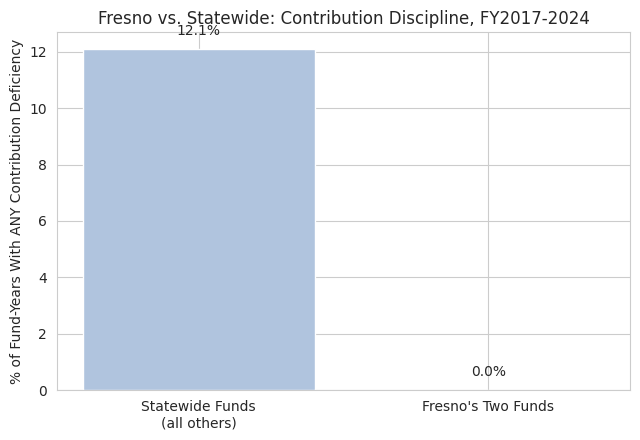

In [40]:
# Compare Fresno specifically against every OTHER fund on contribution discipline
recent = df_clean[df_clean["fiscal_year"] >= 2017].dropna(subset=["contribution_deficiency"])
fresno_ids = df_clean[df_clean["entity_name"].str.contains("Fresno Employees|Fresno Fire")]["entity_id"].unique()

# Split into "Fresno" vs "everyone else" using the entity_id list above
statewide = recent[~recent["entity_id"].isin(fresno_ids)]
fresno_rows = recent[recent["entity_id"].isin(fresno_ids)]

# % of fund-years where deficiency was greater than 0 (i.e., underpaid vs. recommended)
pct_statewide = (statewide["contribution_deficiency"] > 0).mean() * 100
pct_fresno = (fresno_rows["contribution_deficiency"] > 0).mean() * 100

fig, ax = plt.subplots(figsize=(6.5, 4.5))
bars = ax.bar(["Statewide Funds\n(all others)", "Fresno's Two Funds"], [pct_statewide, pct_fresno], color=["lightsteelblue","darkred"])
ax.set_ylabel("% of Fund-Years With ANY Contribution Deficiency")
ax.set_title("Fresno vs. Statewide: Contribution Discipline, FY2017-2024")
# Label each bar with its exact percentage value
for bar, val in zip(bars, [pct_statewide, pct_fresno]):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.5, f"{val:.1f}%", ha="center")
plt.tight_layout()
plt.show()

**What the charts show me:**
- Statewide average funded ratio fell below 100% around 2008-09 and never fully recovered
- Fresno's two funds stayed above the statewide median for all 22 years
- A second, independent chart (contribution deficiency) tells the same story: statewide funds show shortfalls in some years, Fresno shows none

---
## Handing Off to Notebook 2

**Plain-language version:** this notebook's job is done -- the data is clean, merged, and ready. I'm saving it to a file so the next notebook (Modeling and Evaluation) can pick up exactly where this one left off, without needing to redo any of this cleaning work.

**Data-analyst version:** persisting `df_clean` to disk as the single source of truth for every downstream notebook in this collection.

In [41]:
df_clean.to_csv("model_ready_panel_clean.csv", index=False)
print(f"Saved model_ready_panel_clean.csv -- {df_clean.shape[0]} rows, {df_clean.shape[1]} columns")
print("\nNotebook 2 (Modeling and Evaluation) starts by loading this exact file.")

Saved model_ready_panel_clean.csv -- 1761 rows, 24 columns

Notebook 2 (Modeling and Evaluation) starts by loading this exact file.
